In [85]:
# Load model directly
from transformers import AutoProcessor, AutoModelForZeroShotImageClassification
import cv2
import numpy as np
import matplotlib.pyplot as plt
import torch

In [ ]:
processor = AutoProcessor.from_pretrained("patrickjohncyh/fashion-clip")
model = AutoModelForZeroShotImageClassification.from_pretrained("patrickjohncyh/fashion-clip")

In [ ]:
help(processor.__call__)

Help on method __call__ in module transformers.processing_utils:

__call__(images: Union[ForwardRef('PIL.Image.Image'), numpy.ndarray, ForwardRef('torch.Tensor'), list['PIL.Image.Image'], list[numpy.ndarray], list['torch.Tensor'], NoneType] = None, text: Union[str, list[str], list[list[str]], NoneType] = None, videos: Union[list['PIL.Image.Image'], numpy.ndarray, ForwardRef('torch.Tensor'), list[numpy.ndarray], list['torch.Tensor'], list[list['PIL.Image.Image']], list[list[numpy.ndarray]], list[list['torch.Tensor']], transformers.video_utils.URL, list[transformers.video_utils.URL], list[list[transformers.video_utils.URL]], transformers.video_utils.Path, list[transformers.video_utils.Path], list[list[transformers.video_utils.Path]], NoneType] = None, audio: Union[numpy.ndarray, ForwardRef('torch.Tensor'), collections.abc.Sequence[numpy.ndarray], collections.abc.Sequence['torch.Tensor'], NoneType] = None, **kwargs: Unpack[transformers.processing_utils.ProcessingKwargs]) method of transfo

In [70]:
shirt_labels = [
    "a photo of a white shirt",
    "a photo of a black shirt",
    "a photo of a gray shirt",
    "a photo of a red shirt",
    "a photo of a dark red shirt",
    "a photo of a blue shirt",
    "a photo of a light blue shirt",
    "a photo of a navy blue shirt",
    "a photo of a green shirt",
    "a photo of a dark green shirt",
    "a photo of a yellow shirt",
    "a photo of an orange shirt",
    "a photo of a brown shirt",
    "a photo of a beige shirt",
    "a photo of a pink shirt",
    "a photo of a purple shirt",
    "a photo of a dark purple shirt",
    "a photo of a light gray shirt",
    "a photo of a turquoise shirt",
    "a photo of a cyan shirt",
    "a photo of a magenta shirt",
    "a photo of a gold shirt",
    "a photo of a silver shirt",
    "a photo of a maroon shirt",
    "a photo of an olive shirt",
    "a photo of a teal shirt",
    "a photo of a sky blue shirt",
    "a photo of a dark brown shirt",
    "a photo of a violet shirt",
    "a photo of a cream shirt"
]

shirt_labels_short = [
    "a photo of a white shirt",
    "a photo of a black shirt"]

image_list = []
for i in range(1, 8):
    img_path = f"../dark{i}.jpg"
    image = cv2.imread(img_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    image_list.append(image)
#plt.imshow(image)
#image_now = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
#plt.imshow(image_now)
inputs = processor(text=shirt_labels_short, images=image_list, return_tensors="pt", padding=True)

In [71]:
scores = model(**inputs)

scores.logits_per_image[0]

tensor([13.9676, 21.2220], grad_fn=<SelectBackward0>)

<BarContainer object of 2 artists>

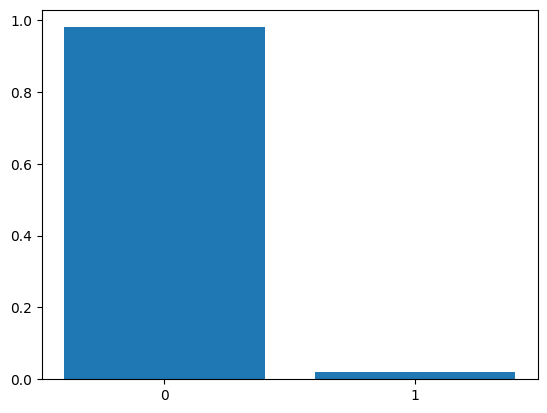

In [76]:
lpi = scores.logits_per_image[6]
probs = lpi.unsqueeze(0).softmax(dim=1)


plt.bar([str(a) for a in np.arange(0, 2, 1)], probs.detach().numpy()[0])

In [87]:
torch.max(scores.logits_per_image.softmax(dim=1), dim=1)

torch.return_types.max(
values=tensor([0.9993, 0.9991, 0.9995, 0.9979, 0.9966, 0.9999, 0.9800],
       grad_fn=<MaxBackward0>),
indices=tensor([1, 1, 1, 1, 1, 1, 0]))